# Goals

1. Run a simulation episode split across multiple control phases, each with its own action and duration
2. Reward function = forward speed - command magnitude - leg extension
3. Plot Reward function


TODO: update 

In [1]:
import sys
print(sys.executable)

import jax
print("jax:", jax.__version__)

/home/imeg2025/Transformable-Leg-Wheel-Robot/.venv/bin/python
jax: 0.6.2


In [2]:
%env MUJOCO_GL=egl

import functools
import os
import time
import mujoco
import numpy as np

import jax
import mediapy as media
from tqdm import tqdm
import twmr  # noqa: F401
import warp as wp
from jax import numpy as jp
from mujoco_playground import registry

wp.config.quiet = True

media.set_ffmpeg("/home/imeg2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")

xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags

# Switch terrain by changing this string. Registered envs:
#   "TWMRLegFlat" — flat plane (trans_wheel_robo2_2FLAT.xml)
#   "TWMRLegTerr" — heightfield (trans_wheel_robo2_2GEN_TERR.xml)
# ENV_NAME = "TWMRLegFlat"
ENV_NAME = "TWMRLegTerr"

env = registry.load(ENV_NAME)
initial_state = env.reset(jax.random.PRNGKey(0))

env: MUJOCO_GL=egl
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.


In [3]:
# ── Phase configuration ───────────────────────────────────────────────────────
N_STEPS = 500  # total simulation steps across all phases

phases = [
    {
        # "action":   jp.array([1.0, 1.0,  1.0, 1.0, 3.0, 3.0, 3.0, 3.0]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0]),
        "action":   jp.array([0.0, 0.0,  0.0, 0.0, -3.0, -3.0, -3.0, -3.0]),
        
        
        "fraction": 0.30,  # 30% of N_STEPS
    },
    {
        # "action":   jp.array([0.8, 0.8, 0.8,  0.8, 0.0, 0.0, 0.0, 0.0]),
        "action":   jp.array([0.8, 0.8, 0.8,  0.8, -3.0, -3.0, -3.0, -3.0]),
        "action":   jp.array([0.8, 0.8, 0.8,  0.8, -0.1, -0.1, -0.1, -0.1]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, -3.0, -3.0, -3.0, -3.0]),
        # "action":   jp.array([0.0, 0.0,  0.0, 0.0, 3.0, 3.0, 3.0, 3.0]),
        
        
        "fraction": 0.70,  # 70% of N_STEPS
    },
]
# ─────────────────────────────────────────────────────────────────────────────

assert abs(sum(p["fraction"] for p in phases) - 1.0) < 1e-6, \
    "Phase fractions must sum to 1.0"

# Compute integer step counts; last phase absorbs any rounding remainder
step_counts = [round(N_STEPS * p["fraction"]) for p in phases]
step_counts[-1] = N_STEPS - sum(step_counts[:-1])


# n_steps must be a compile-time constant for jax.lax.scan,
# so mark it static — each unique value triggers one JIT compilation.
@functools.partial(jax.jit, static_argnums=(2,))
def run_phase(initial_state, action, n_steps):
    def step_fn(state, _):
        state = env.step(state=state, action=action)
        return state, state
    return jax.lax.scan(step_fn, initial_state, None, length=n_steps)


state = initial_state
rollouts = []  # one stacked-State per phase

for i, (phase, n) in enumerate(zip(phases, step_counts)):
    print(f"Phase {i + 1}: {n} steps (action={phase['action'].tolist()}) ...")
    t0 = time.perf_counter()
    state, rollout = run_phase(state, phase["action"], n)
    rollout.data.qpos.block_until_ready()
    t1 = time.perf_counter()
    print(f"  done in {t1 - t0:.2f}s  ({n / (t1 - t0):.0f} steps/s)")
    rollouts.append(rollout)

print(f"\nFinal position: {state.data.qpos}")

Phase 1: 150 steps (action=[0.0, 0.0, 0.0, 0.0, -3.0, -3.0, -3.0, -3.0]) ...
  done in 3.39s  (44 steps/s)
Phase 2: 350 steps (action=[0.800000011920929, 0.800000011920929, 0.800000011920929, 0.800000011920929, -0.10000000149011612, -0.10000000149011612, -0.10000000149011612, -0.10000000149011612]) ...
  done in 4.75s  (74 steps/s)

Final position: [ 0.77819836 -0.07077013  0.1575884   0.32498    -0.11926822 -0.92907983
 -0.13028431 27.659153    0.97271216  0.9727154   0.9727172  28.816435
  0.963108    0.96310633  0.96309984 25.326374    1.4205462   1.4213437
  1.4203892  28.697515    0.87198114  0.8720699   0.872064  ]


In [4]:
# ── Adjustable camera parameter ──────────────────────────────────────────────
camera_distance = 1.5  # meters; increase to zoom out, decrease to zoom in
# ─────────────────────────────────────────────────────────────────────────────


def render_phases(env, rollouts, camera_distance=1.5, height=480, width=640):
    """Render a list of phase rollouts (each a stacked State) into one video."""
    mj_model = env.mj_model
    renderer = mujoco.Renderer(mj_model, height=height, width=width)

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, cam)
    cam.azimuth = 135.0    # 3/4 rear view
    cam.elevation = -20.0  # slight downward angle
    cam.distance = camera_distance

    chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "chassis")
    if chassis_id < 0:
        chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "root")
    if chassis_id < 0:
        chassis_id = 1

    # Pull all phases to CPU and concatenate along the time axis
    all_qpos       = np.concatenate([np.array(r.data.qpos)        for r in rollouts])
    all_qvel       = np.concatenate([np.array(r.data.qvel)        for r in rollouts])
    all_mocap_pos  = np.concatenate([np.array(r.data.mocap_pos)   for r in rollouts])
    all_mocap_quat = np.concatenate([np.array(r.data.mocap_quat)  for r in rollouts])
    all_xfrc       = np.concatenate([np.array(r.data.xfrc_applied) for r in rollouts])

    frames = []
    d = mujoco.MjData(mj_model)
    for i in tqdm(range(all_qpos.shape[0]), desc="Rendering frames"):
        d.qpos[:]        = all_qpos[i]
        d.qvel[:]        = all_qvel[i]
        d.mocap_pos[:]   = all_mocap_pos[i]
        d.mocap_quat[:]  = all_mocap_quat[i]
        d.xfrc_applied[:] = all_xfrc[i]
        mujoco.mj_forward(mj_model, d)

        cam.lookat[:] = d.xpos[chassis_id]
        renderer.update_scene(d, camera=cam)
        frames.append(renderer.render())

    renderer.close()
    return frames


frames = render_phases(env, rollouts, camera_distance=camera_distance)

media.show_video(frames, fps=1.0 / env.dt)
media.write_video("tlwr_demo_modes.mp4", frames, fps=1.0 / env.dt)

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

Rendering frames: 100%|██████████████████████████████████| 500/500 [00:10<00:00, 47.15it/s]


This browser does not support the video tag.


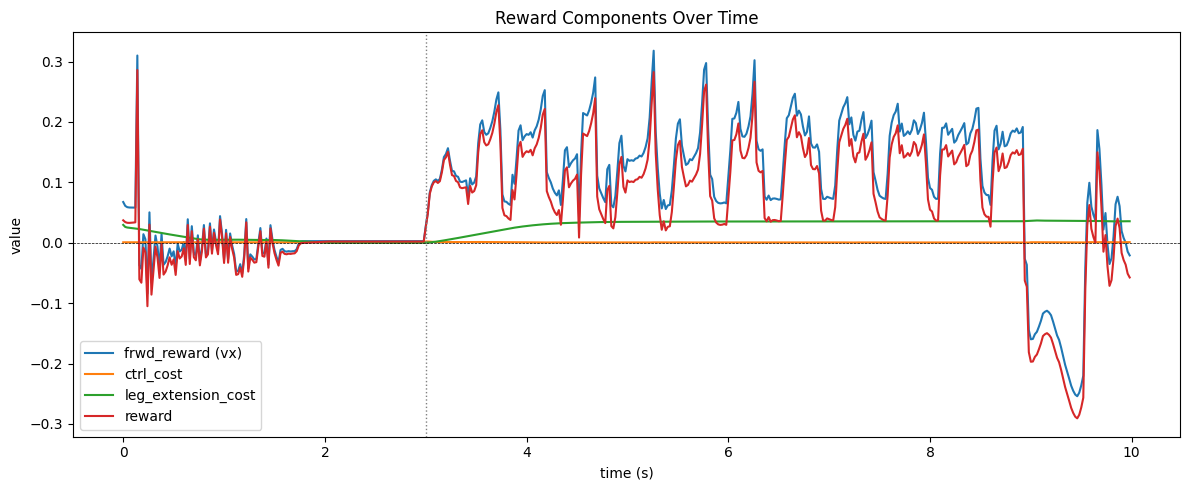

In [5]:
import matplotlib.pyplot as plt

# Concatenate data from all phases
all_qpos = np.concatenate([np.array(r.data.qpos) for r in rollouts])  # (T, nq)
all_qvel = np.concatenate([np.array(r.data.qvel) for r in rollouts])  # (T, nv)
all_ctrl = np.concatenate([np.array(r.data.ctrl) for r in rollouts])  # (T, nu)

### Per-step reward components

# Forward reward & control cost
vx          = all_qvel[:, 0]
frwd_reward = vx
ctrl_cost   = 0.0005 * np.sum(np.square(all_ctrl), axis=1)

# Leg extension cost: 0 when contracted, max when fully extended, linear
LEG_MIN = -1.047   # rad: contracted position
LEG_MAX =  3.427   # rad: fully extended position
LEG_FULL_EXTENDED = (LEG_MAX + LEG_MIN) / 2
HALF_RANGE = (LEG_MAX - LEG_MIN)/2 # rad: angle from fully contracted --> fully extended
leg_angles            = all_qpos[:, [8, 12, 16, 20]]                        # (T, 4)
leg_angles_normalized = 1 - (abs(leg_angles - LEG_FULL_EXTENDED)) / HALF_RANGE        # [0, 1] (1 --> extended, 0 --> contracted)
leg_extension_cost    = 0.01 * np.sum(leg_angles_normalized, axis=1)        # linear, (T,) CAN CHANGE TO QUADRATIC

reward = frwd_reward - ctrl_cost - leg_extension_cost

# Time axis
t = np.arange(len(vx)) * float(env.dt)

# Phase boundary lines
phase_boundaries = np.cumsum(step_counts[:-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, frwd_reward,       label="frwd_reward (vx)")
ax.plot(t, ctrl_cost,         label="ctrl_cost")
ax.plot(t, leg_extension_cost, label="leg_extension_cost")
ax.plot(t, reward,            label="reward")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
for pb in phase_boundaries:
    ax.axvline(t[pb], color="gray", linewidth=1.0, linestyle=":", label="_phase boundary")
ax.set_xlabel("time (s)")
ax.set_ylabel("value")
ax.set_title("Reward Components Over Time")
ax.legend()
plt.tight_layout()
plt.show()

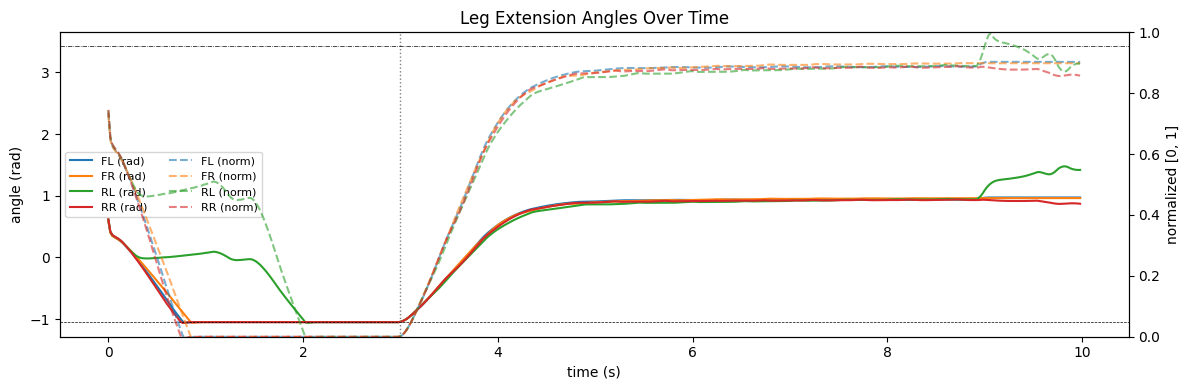

In [6]:
all_qpos_plot = np.concatenate([np.array(r.data.qpos) for r in rollouts])
leg_angles_plot = all_qpos_plot[:, [8, 12, 16, 20]]
leg_angles_norm_plot = 1 - (abs(leg_angles_plot - LEG_FULL_EXTENDED)) / HALF_RANGE
t_plot = np.arange(len(leg_angles_plot)) * float(env.dt)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, name in enumerate(["FL", "FR", "RL", "RR"]):
    
    ax1.plot(t_plot, leg_angles_plot[:, i],      color=colors[i], linestyle="-",  label=f"{name} (rad)")
    ax2.plot(t_plot, leg_angles_norm_plot[:, i], color=colors[i], linestyle="--", alpha=0.6, label=f"{name} (norm)")

for pb in phase_boundaries:
    ax1.axvline(t_plot[pb], color="gray", linewidth=1.0, linestyle=":")
ax1.axhline(LEG_MIN, color="k", linewidth=0.5, linestyle="--")
ax1.axhline(LEG_MAX, color="k", linewidth=0.5, linestyle="-.")

ax1.set_xlabel("time (s)")
ax1.set_ylabel("angle (rad)")
ax2.set_ylabel("normalized [0, 1]")
ax2.set_ylim(0, 1)
ax1.set_title("Leg Extension Angles Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

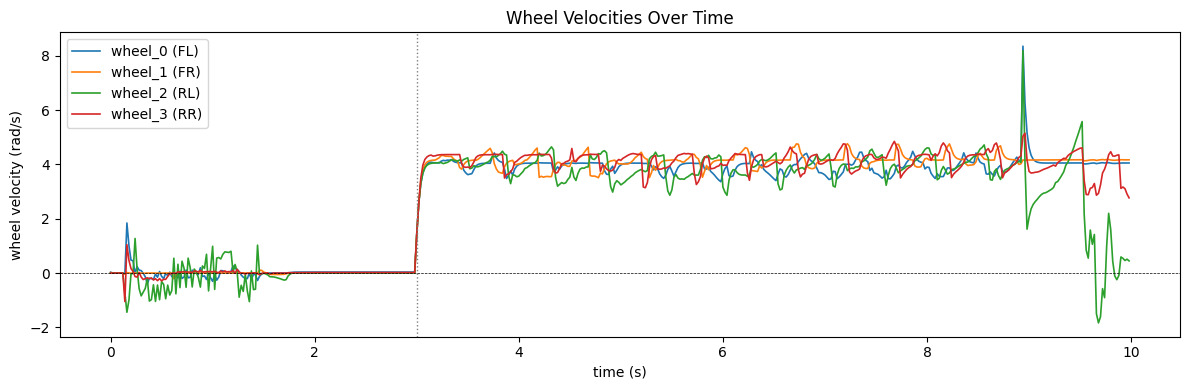

In [7]:
# ── Wheel velocities ─────────────────────────────────────────────────────────
# Indices match _WHEEL_QVEL_IDX in twmr.py ([6, 10, 14, 18]),
# which follow the XML joint declaration order:
#   qvel[6]  = front_left_wheel_joint   → wheel_0
#   qvel[10] = front_right_wheel_joint  → wheel_1
#   qvel[14] = rear_left_wheel_joint    → wheel_2
#   qvel[18] = rear_right_wheel_joint   → wheel_3
# This is the same order used by action[:4] → actuators (lines 171-174 of the XML)
# and by the train_jax_ppo desired wheel velocity plot.
WHEEL_QVEL_IDX = [6, 10, 14, 18]
wheel_vel = all_qvel[:, WHEEL_QVEL_IDX]  # (T, 4)

fig, ax = plt.subplots(figsize=(12, 4))
for i, name in enumerate(["wheel_0 (FL)", "wheel_1 (FR)", "wheel_2 (RL)", "wheel_3 (RR)"]):
    ax.plot(t, wheel_vel[:, i], linewidth=1.2, label=name)
for pb in phase_boundaries:
    ax.axvline(t[pb], color="gray", linewidth=1.0, linestyle=":")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlabel("time (s)")
ax.set_ylabel("wheel velocity (rad/s)")
ax.set_title("Wheel Velocities Over Time")
ax.legend()
plt.tight_layout()
plt.show()

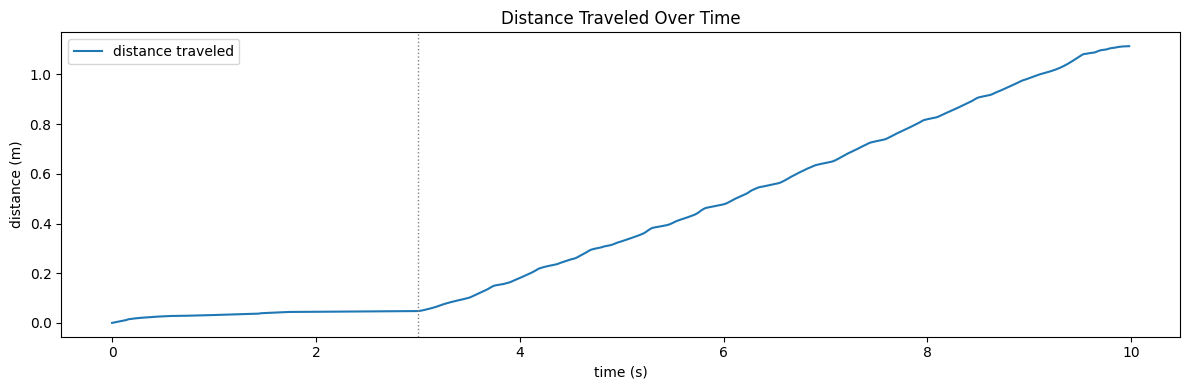

Total distance traveled: 1.114 m


In [8]:
# ── Distance traveled ────────────────────────────────────────────────────────
# Cumulative path length of the chassis in the xy-plane (meters).
# qpos[:, 0:2] are the chassis x, y positions (free joint).
xy = all_qpos[:, :2]  # (T, 2)
step_dist = np.linalg.norm(np.diff(xy, axis=0), axis=1)  # (T-1,)
distance_traveled = np.concatenate([[0.0], np.cumsum(step_dist)])  # (T,)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, distance_traveled, linewidth=1.5, label="distance traveled")
for pb in phase_boundaries:
    ax.axvline(t[pb], color="gray", linewidth=1.0, linestyle=":")
ax.set_xlabel("time (s)")
ax.set_ylabel("distance (m)")
ax.set_title("Distance Traveled Over Time")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total distance traveled: {distance_traveled[-1]:.3f} m")